In [11]:
# ============================================
# CREATE REQUIRED FOLDERS
# ============================================
import os

# Create folders
os.makedirs('reports/figures', exist_ok=True)
os.makedirs('data/processed', exist_ok=True)
os.makedirs('data/splits', exist_ok=True)
os.makedirs('models/encoders', exist_ok=True)

print("✅ All folders created!")

✅ All folders created!


📦 SECTION 1: SETUP AND IMPORTS

In [12]:
# ============================================
# 🍄 MUSHROOM CLASSIFICATION PROJECT
# NOTEBOOK 2: Data Preprocessing
# ============================================

# ----- 2.1: IMPORT LIBRARIES -----
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
import warnings
import os
import pickle
warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")

print("=" * 60)
print("🍄 DATA PREPROCESSING")
print("=" * 60)
print("\n✅ All libraries imported successfully!")

🍄 DATA PREPROCESSING

✅ All libraries imported successfully!


📥 SECTION 2: LOAD THE DATASET

In [13]:
# ----- 2.2: LOAD THE DATASET -----

# Column names
column_names = [
    'class', 'cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor',
    'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color',
    'stalk-shape', 'stalk-root', 'stalk-surface-above-ring', 'stalk-surface-below-ring',
    'stalk-color-above-ring', 'stalk-color-below-ring', 'veil-type', 'veil-color',
    'ring-number', 'ring-type', 'spore-print-color', 'population', 'habitat'
]

# Try different paths
paths_to_try = [
    '../data/raw/mushrooms.csv',
    'data/raw/mushrooms.csv',
    'mushrooms.csv'
]

df = None
for path in paths_to_try:
    try:
        df = pd.read_csv(path, names=column_names, header=0)
        print(f"✅ Loaded from: {path}")
        break
    except:
        continue

print(f"\n📊 Dataset shape: {df.shape}")
print(f"   Rows: {df.shape[0]}")
print(f"   Columns: {df.shape[1]}")
print(f"\n📋 First 5 rows:")
display(df.head())

✅ Loaded from: ../data/raw/mushrooms.csv

📊 Dataset shape: (8124, 23)
   Rows: 8124
   Columns: 23

📋 First 5 rows:


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


SECTION 3: CHECK FOR MISSING VALUES

In [14]:
# ----- 2.3: MISSING VALUE ANALYSIS -----

print("=" * 60)
print("🔍 MISSING VALUE ANALYSIS")
print("=" * 60)

# Check unique values in each column
print("\n📊 Unique values per column:")
for col in df.columns:
    unique_vals = df[col].unique()
    print(f"   {col}: {len(unique_vals)} unique values - {list(unique_vals)[:5]}...")

# Check for '?' values (these represent missing data in this dataset)
print("\n🔍 Checking for '?' values (missing data indicator):")
missing_info = {}
for col in df.columns:
    question_count = (df[col] == '?').sum()
    if question_count > 0:
        missing_info[col] = question_count
        print(f"   ⚠️ {col}: {question_count} missing values ({question_count/len(df)*100:.2f}%)")

if len(missing_info) == 0:
    print("   ✅ No '?' values found!")
else:
    print(f"\n📊 Total columns with missing values: {len(missing_info)}")
    
# Check for actual NaN values
print("\n🔍 Checking for NaN values:")
nan_counts = df.isna().sum()
if nan_counts.sum() == 0:
    print("   ✅ No NaN values found!")
else:
    print(f"   ⚠️ NaN values found in: {nan_counts[nan_counts > 0].index.tolist()}")

🔍 MISSING VALUE ANALYSIS

📊 Unique values per column:
   class: 2 unique values - ['p', 'e']...
   cap-shape: 6 unique values - ['x', 'b', 's', 'f', 'k']...
   cap-surface: 4 unique values - ['s', 'y', 'f', 'g']...
   cap-color: 10 unique values - ['n', 'y', 'w', 'g', 'e']...
   bruises: 2 unique values - ['t', 'f']...
   odor: 9 unique values - ['p', 'a', 'l', 'n', 'f']...
   gill-attachment: 2 unique values - ['f', 'a']...
   gill-spacing: 2 unique values - ['c', 'w']...
   gill-size: 2 unique values - ['n', 'b']...
   gill-color: 12 unique values - ['k', 'n', 'g', 'p', 'w']...
   stalk-shape: 2 unique values - ['e', 't']...
   stalk-root: 5 unique values - ['e', 'c', 'b', 'r', '?']...
   stalk-surface-above-ring: 4 unique values - ['s', 'f', 'k', 'y']...
   stalk-surface-below-ring: 4 unique values - ['s', 'f', 'y', 'k']...
   stalk-color-above-ring: 9 unique values - ['w', 'g', 'p', 'n', 'b']...
   stalk-color-below-ring: 9 unique values - ['w', 'p', 'g', 'b', 'n']...
   veil-type:

🔧 SECTION 4: HANDLE MISSING VALUES IN STALK-ROOT

🔧 HANDLING MISSING VALUES

📊 Stalk-root '?' count: 2480 (30.53%)

📊 Stalk-root distribution by class (excluding '?'):


class,e,p
stalk-root,,
b,1920.0,1856.0
c,512.0,44.0
e,864.0,256.0
r,192.0,0.0



🔧 Strategy: Replace '?' with most common stalk-root for each class
   Edible mode: 'b'
   Poisonous mode: 'b'

✅ Remaining '?' values: 0


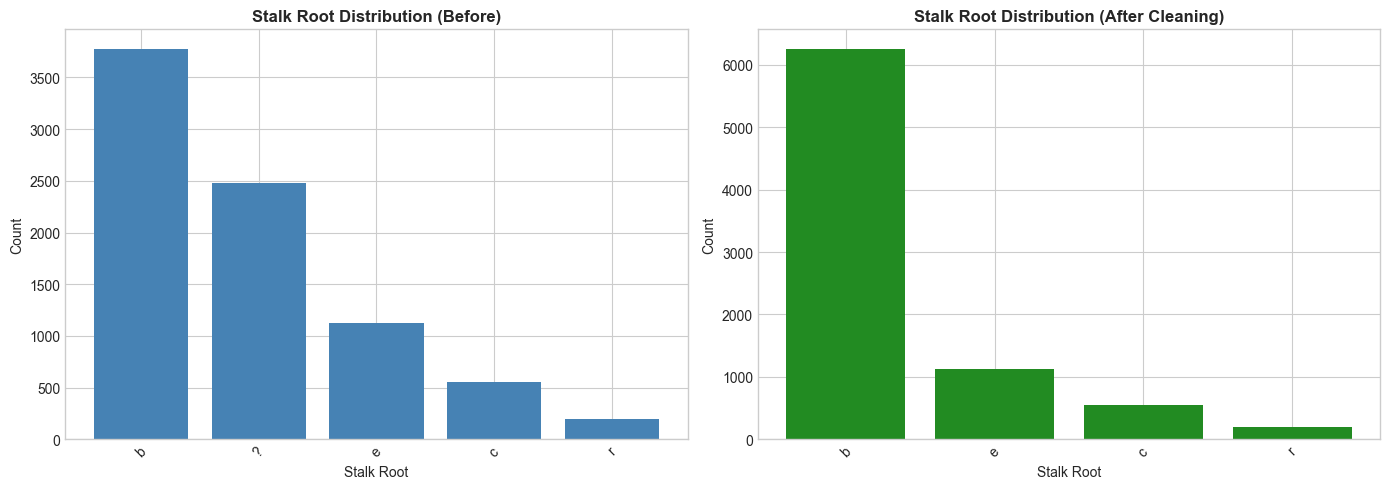


✅ Missing values handled successfully!


In [15]:
# ----- 2.4: HANDLE MISSING VALUES IN STALK-ROOT -----

print("=" * 60)
print("🔧 HANDLING MISSING VALUES")
print("=" * 60)

# Count '?' in stalk-root
question_count = (df['stalk-root'] == '?').sum()
print(f"\n📊 Stalk-root '?' count: {question_count} ({question_count/len(df)*100:.2f}%)")

# Analyze stalk-root distribution by class
print("\n📊 Stalk-root distribution by class (excluding '?'):")
stalk_root_dist = df[df['stalk-root'] != '?'].groupby('stalk-root')['class'].value_counts().unstack().fillna(0)
display(stalk_root_dist)

# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before handling
before_counts = df['stalk-root'].value_counts()
axes[0].bar(before_counts.index, before_counts.values, color='steelblue')
axes[0].set_title('Stalk Root Distribution (Before)', fontweight='bold')
axes[0].set_xlabel('Stalk Root')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Strategy: Replace '?' with the most common value for each class
print("\n🔧 Strategy: Replace '?' with most common stalk-root for each class")

# Find most common stalk-root for edible mushrooms
edible_mode = df[(df['class'] == 'e') & (df['stalk-root'] != '?')]['stalk-root'].mode()[0]
print(f"   Edible mode: '{edible_mode}'")

# Find most common stalk-root for poisonous mushrooms
poisonous_mode = df[(df['class'] == 'p') & (df['stalk-root'] != '?')]['stalk-root'].mode()[0]
print(f"   Poisonous mode: '{poisonous_mode}'")

# Create a copy for cleaning
df_clean = df.copy()

# Replace '?' with class-specific mode
df_clean.loc[(df_clean['class'] == 'e') & (df_clean['stalk-root'] == '?'), 'stalk-root'] = edible_mode
df_clean.loc[(df_clean['class'] == 'p') & (df_clean['stalk-root'] == '?'), 'stalk-root'] = poisonous_mode

# Verify replacement
remaining_questions = (df_clean['stalk-root'] == '?').sum()
print(f"\n✅ Remaining '?' values: {remaining_questions}")

# After handling
after_counts = df_clean['stalk-root'].value_counts()
axes[1].bar(after_counts.index, after_counts.values, color='forestgreen')
axes[1].set_title('Stalk Root Distribution (After Cleaning)', fontweight='bold')
axes[1].set_xlabel('Stalk Root')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('reports/figures/stalk_root_cleaning.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Missing values handled successfully!")

 SECTION 5: ENCODE TARGET (Simplified)

In [16]:
# ============================================
# ENCODE TARGET VARIABLE
# ============================================

df_encoded = df_clean.copy()
df_encoded['class'] = df_encoded['class'].map({'e': 1, 'p': 0})

print("✅ Target encoded: e→1 (edible), p→0 (poisonous)")
print(f"Edible (1): {df_encoded['class'].sum()}")
print(f"Poisonous (0): {len(df_encoded) - df_encoded['class'].sum()}")
display(df_encoded[['class']].head())

✅ Target encoded: e→1 (edible), p→0 (poisonous)
Edible (1): 4208
Poisonous (0): 3916


,class
0,0
1,1
2,1
3,0
4,1


🔄 SECTION 6: LABEL ENCODE FEATURES (Simplified)

In [17]:
# ============================================
# LABEL ENCODE ALL FEATURES
# ============================================

from sklearn.preprocessing import LabelEncoder

df_label = df_encoded.copy()
encoders = {}

for col in df_label.columns[1:]:  # Skip class
    le = LabelEncoder()
    df_label[col] = le.fit_transform(df_label[col].astype(str))
    encoders[col] = le

print(f"✅ {len(encoders)} features label encoded!")
print("\nFirst 5 rows:")
display(df_label.head())

✅ 22 features label encoded!

First 5 rows:


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,0,5,2,4,1,6,1,0,1,4,...,2,7,7,0,2,1,4,2,3,5
1,1,5,2,9,1,0,1,0,0,4,...,2,7,7,0,2,1,4,3,2,1
2,1,0,2,8,1,3,1,0,0,5,...,2,7,7,0,2,1,4,3,2,3
3,0,5,3,8,1,6,1,0,1,5,...,2,7,7,0,2,1,4,2,3,5
4,1,5,2,3,0,5,1,1,0,4,...,2,7,7,0,2,1,0,3,0,1


✂️ SECTION 7: TRAIN/VAL/TEST SPLIT (Simplified)

In [18]:
# ============================================
# TRAIN / VALIDATION / TEST SPLIT
# ============================================

from sklearn.model_selection import train_test_split

X = df_label.drop('class', axis=1)
y = df_label['class']

# Split: 60% train, 20% val, 20% test
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)

print("✅ Data split complete!")
print(f"   Train: {len(X_train)} ({len(X_train)/len(df)*100:.1f}%)")
print(f"   Val:   {len(X_val)} ({len(X_val)/len(df)*100:.1f}%)")
print(f"   Test:  {len(X_test)} ({len(X_test)/len(df)*100:.1f}%)")

# Quick check
print(f"\nClass balance in train: {y_train.sum()/len(y_train)*100:.1f}% edible")

✅ Data split complete!
   Train: 4874 (60.0%)
   Val:   1625 (20.0%)
   Test:  1625 (20.0%)

Class balance in train: 51.8% edible


💾 SECTION 8: SAVE DATA (Simplified)

In [23]:
# ============================================
# SAVE PROCESSED DATA
# ============================================

os.makedirs('data/processed', exist_ok=True)
os.makedirs('data/splits', exist_ok=True)
os.makedirs('models/encoders', exist_ok=True)

# Save
df_label.to_csv('data/processed/mushrooms_label_encoded.csv', index=False)
X_train.to_csv('data/splits/X_train.csv', index=False)
X_val.to_csv('data/splits/X_val.csv', index=False)
X_test.to_csv('data/splits/X_test.csv', index=False)
y_train.to_csv('data/splits/y_train.csv', index=False)
y_val.to_csv('data/splits/y_val.csv', index=False)
y_test.to_csv('data/splits/y_test.csv', index=False)

with open('models/encoders/label_encoders.pkl', 'wb') as f:
    pickle.dump(encoders, f)

print("✅ All files saved!")
print("\n📁 Saved:")
print("   • data/processed/mushrooms_label_encoded.csv")
print("   • data/splits/X_train.csv, X_val.csv, X_test.csv")
print("   • data/splits/y_train.csv, y_val.csv, y_test.csv")
print("   • models/encoders/label_encoders.pkl")

✅ All files saved!

📁 Saved:
   • data/processed/mushrooms_label_encoded.csv
   • data/splits/X_train.csv, X_val.csv, X_test.csv
   • data/splits/y_train.csv, y_val.csv, y_test.csv
   • models/encoders/label_encoders.pkl


🎉 SECTION 9: COMPLETION

In [20]:
print("=" * 50)
print("🎉 NOTEBOOK 2 COMPLETED!")
print("=" * 50)
print("\n✅ Data is clean and encoded")
print("✅ Train/Val/Test splits created")
print("✅ All files saved")
print("\n🚀 Ready for Notebook 3: Feature Engineering!")

🎉 NOTEBOOK 2 COMPLETED!

✅ Data is clean and encoded
✅ Train/Val/Test splits created
✅ All files saved

🚀 Ready for Notebook 3: Feature Engineering!


In [24]:
import os
import pickle

# Create folders using exact paths
os.makedirs('data/splits', exist_ok=True)
os.makedirs('models/encoders', exist_ok=True)

# Save all files
df_label.to_csv('data/processed/mushrooms_label_encoded.csv', index=False)
X_train.to_csv('data/splits/X_train.csv', index=False)
X_val.to_csv('data/splits/X_val.csv', index=False)
X_test.to_csv('data/splits/X_test.csv', index=False)
y_train.to_csv('data/splits/y_train.csv', index=False)
y_val.to_csv('data/splits/y_val.csv', index=False)
y_test.to_csv('data/splits/y_test.csv', index=False)

with open('models/encoders/label_encoders.pkl', 'wb') as f:
    pickle.dump(encoders, f)

# Verify immediately
import os
print("\n📁 Files in data/splits/:")
if os.path.exists('data/splits'):
    for file in os.listdir('data/splits'):
        print(f"   ✅ {file}")
else:
    print("   ❌ Folder not created!")

print("\n📁 Files in models/encoders/:")
if os.path.exists('models/encoders'):
    for file in os.listdir('models/encoders'):
        print(f"   ✅ {file}")
else:
    print("   ❌ Folder not created!")


📁 Files in data/splits/:
   ✅ X_test.csv
   ✅ X_test_scaled.csv
   ✅ X_train.csv
   ✅ X_train_scaled.csv
   ✅ X_val.csv
   ✅ X_val_scaled.csv
   ✅ y_test.csv
   ✅ y_train.csv
   ✅ y_val.csv

📁 Files in models/encoders/:
   ✅ label_encoders.pkl
   ✅ rf_feature_importance.pkl
